<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# extended-data-weekly-outputs-compare

This notebook is part of the capstone project’s Bayesian Optimisation (BBO) challenge. It compares the weekly output results using percentage changes and absolute differences.

The maximum value is marked with an asterisk (`*`). Note that some weekly data was intentionally excluded because it did not align with the assignment guidelines, such as query points above 1 or outputs that were not sensible beyond the boundary conditions.

This notebook was submitted after **Module 25: Final BBO Capstone Project Submission: GitHub Repository**.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.api as sm

from matplotlib.ticker import PercentFormatter

# Compare the results in percentage

In [2]:
# Read the data
df = pd.read_excel(open("extended_data/CapstoneFunction_WeeklyOutputs_Compare.xlsx", "rb"), sheet_name="Compare")

In [3]:
df.head(15)

,Review,F1,F2,F3,F4,F5,F6,F7,F8
0,Initial,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,W2,-9.999998e-01,-1.066511,-0.452993,-0.771718,0.680483,-0.738775,-0.565709,-0.138938
2,W3,-1.000000e+00,-0.233085,0.439989,1.050625,-0.347389,0.505863,0.900995,-0.234151
3,W4,-5.064935e+07,-0.202292,-2.428305,0.753674,1.478836,-0.172254,-0.202882,0.016836
4,W5,-1.000000e+00,0.057825,0.386910,0.753704,1.919926,-1.055862,-0.039514,-0.104980
5,W6,-1.000000e+00,-0.053776,0.567332,0.219480,1.622138,0.363568,0.560705,0.002242
6,W7,-9.610390e+09,-0.077974,-0.997962,1.163297,3.097171,-0.203060,0.511822,0.004139
7,W8,-9.997390e-01,0.117772,0.326884,1.164966,3.432420,0.088889,0.203639,0.016069
8,W9,7.935065e+00,0.040687,0.159782,1.117284,3.612870,0.526253,1.014119,0.013723
9,W10,4.120679e+04,-0.164042,0.468466,1.067971,12.457529,-0.524408,0.291139,0.032277


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Review  13 non-null     object 
 1   F1      13 non-null     float64
 2   F2      13 non-null     float64
 3   F3      13 non-null     float64
 4   F4      13 non-null     float64
 5   F5      13 non-null     float64
 6   F6      13 non-null     float64
 7   F7      13 non-null     float64
 8   F8      13 non-null     float64
dtypes: float64(8), object(1)
memory usage: 1.0+ KB


In [5]:
df = df.set_index('Review')  # use week labels (W2, W3, ...) as x-axis

In [6]:
df.head(2)

,F1,F2,F3,F4,F5,F6,F7,F8
Review,,,,,,,,
Initial,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
W2,-1.0,-1.066511,-0.452993,-0.771718,0.680483,-0.738775,-0.565709,-0.138938


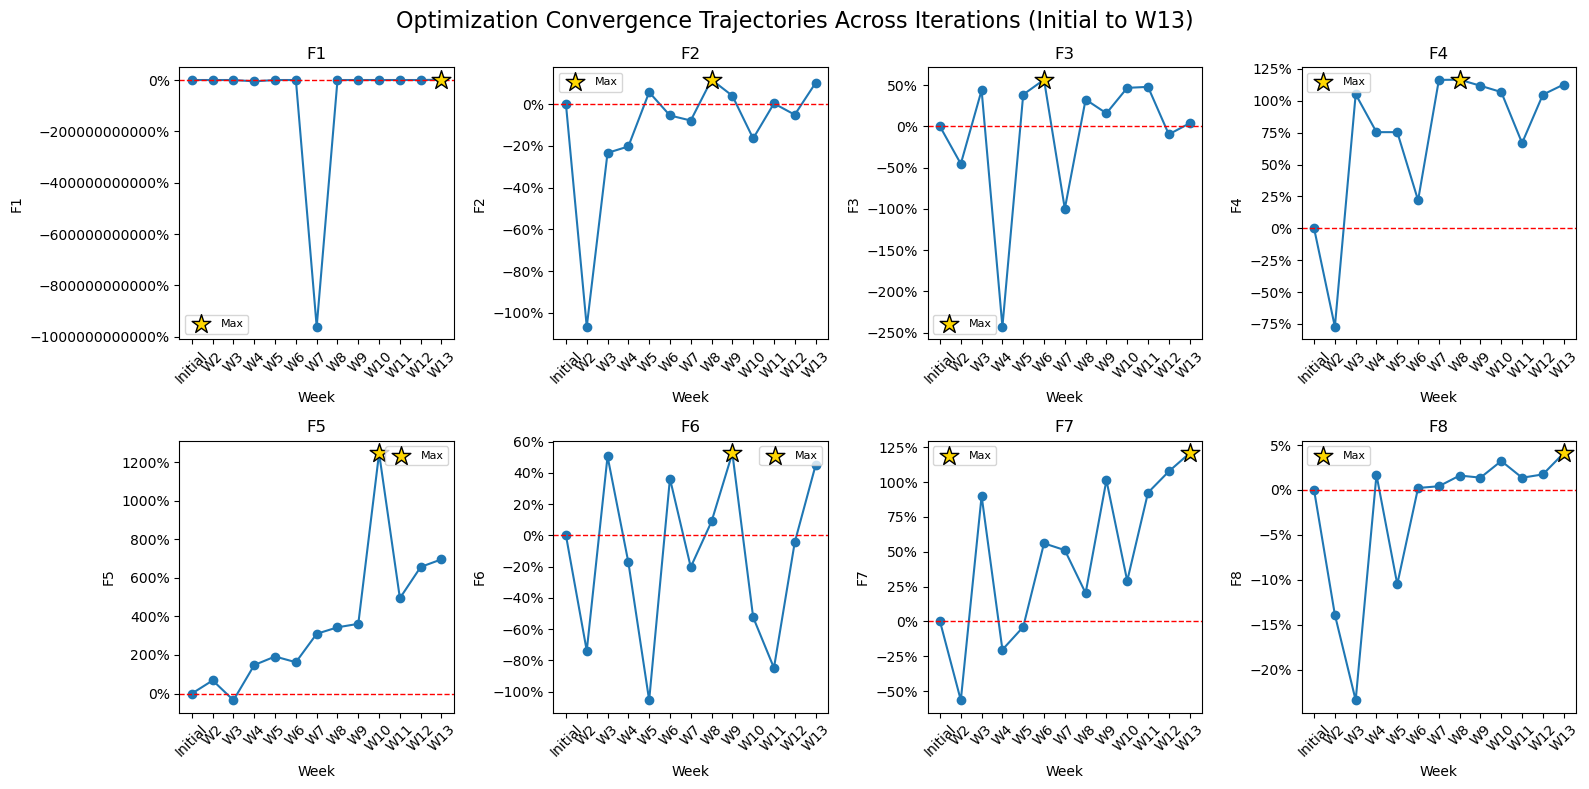

In [7]:
n_cols = df.shape[1]
ncols = 4
nrows = -(-n_cols // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].plot(df.index, df[col], marker='o', color='tab:blue')
    axes[i].axhline(0, color='red', linewidth=1, linestyle='--')              # <-- zero line

    # Highlight the maximum value with a star marker
    max_week = df[col].idxmax()
    max_val = df[col].max()
    axes[i].scatter(max_week, max_val, marker='*', s=200, color='gold',
                     edgecolor='black', zorder=5, label='Max')

    axes[i].set_title(col)
    axes[i].set_xlabel('Week')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))  # <-- y-ticks as %
    axes[i].legend(fontsize=8)

for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Optimization Convergence Trajectories Across Iterations (Initial to W13)', fontsize=16)

plt.tight_layout()
# plt.savefig('extended-data-weekly-outputs-compare.png', dpi=150)
plt.show()

# Compare the direct output values

In [8]:
# Read the data
do = pd.read_excel(open("extended_data/CapstoneFunction_WeeklyOutputs_Compare.xlsx", "rb"), sheet_name="Output")

In [9]:
do.head(15)

,Review,F1,F2,F3,F4,F5,F6,F7,F8
0,Initial,7.700000e-16,0.611205,-0.034835,-4.025542,1088.859618,-0.714265,1.364968,9.598482
1,W2,1.300000e-22,-0.040652,-0.050615,-7.132125,1829.809875,-1.241946,0.592794,8.264884
2,W3,2.000000e-50,0.468742,-0.019508,0.203794,710.602251,-0.352945,2.594798,7.350985
3,W4,-3.900000e-08,0.487563,-0.119425,-0.991595,2699.104490,-0.837300,1.088041,9.760084
4,W5,5.200000e-188,0.646548,-0.021357,-0.991473,3179.389393,-1.468430,1.311033,8.590830
5,W6,8.070000e-24,0.578337,-0.015072,-3.142015,2855.140103,-0.454581,2.130313,9.619999
6,W7,-7.400000e-06,0.563547,-0.069599,0.657359,4461.243621,-0.859304,2.063588,9.638209
7,W8,2.010000e-19,0.683188,-0.023448,0.664078,4826.282688,-0.650775,1.642929,9.752723
8,W9,6.880000e-15,0.636073,-0.029269,0.472130,5022.767512,-0.338381,2.749208,9.730201
9,W10,3.173000e-11,0.510942,-0.018516,0.273622,14653.360405,-1.088831,1.762364,9.908295


In [10]:
do = do.set_index('Review')  # use week labels (W2, W3, ...) as x-axis

In [11]:
do.head(2)

,F1,F2,F3,F4,F5,F6,F7,F8
Review,,,,,,,,
Initial,7.700000e-16,0.611205,-0.034835,-4.025542,1088.859618,-0.714265,1.364968,9.598482
W2,1.300000e-22,-0.040652,-0.050615,-7.132125,1829.809875,-1.241946,0.592794,8.264884


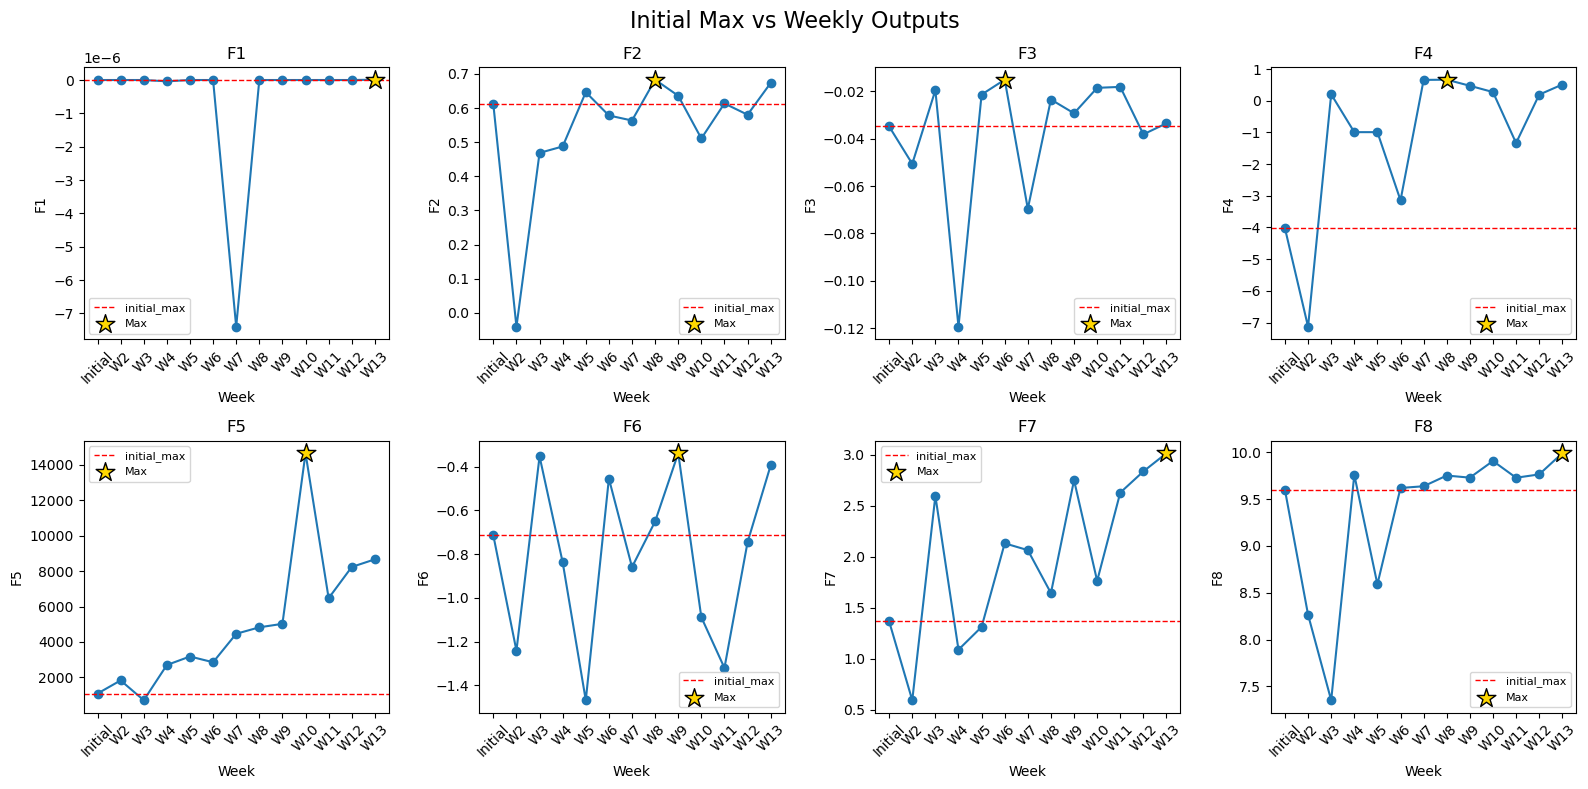

In [12]:
n_cols = do.shape[1]
ncols = 4
nrows = -(-n_cols // ncols)

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(do.columns):
    axes[i].plot(do.index, do[col], marker='o', color='tab:blue')

    # Red line at the Initial Max value
    initial_val = do.loc['Initial', col]
    axes[i].axhline(initial_val, color='red', linewidth=1, linestyle='--', label='initial_max')

    # Highlight the maximum value with a star marker
    max_week = do[col].idxmax()
    max_val = do[col].max()
    axes[i].scatter(max_week, max_val, marker='*', s=200, color='gold',
                     edgecolor='black', zorder=5, label='Max')

    axes[i].set_title(col)
    axes[i].set_xlabel('Week')
    axes[i].set_ylabel(col)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].legend(fontsize=8)

for j in range(n_cols, len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Initial Max vs Weekly Outputs', fontsize=16)

plt.tight_layout()
plt.show()

# Compare (Exclude Irrelevance)

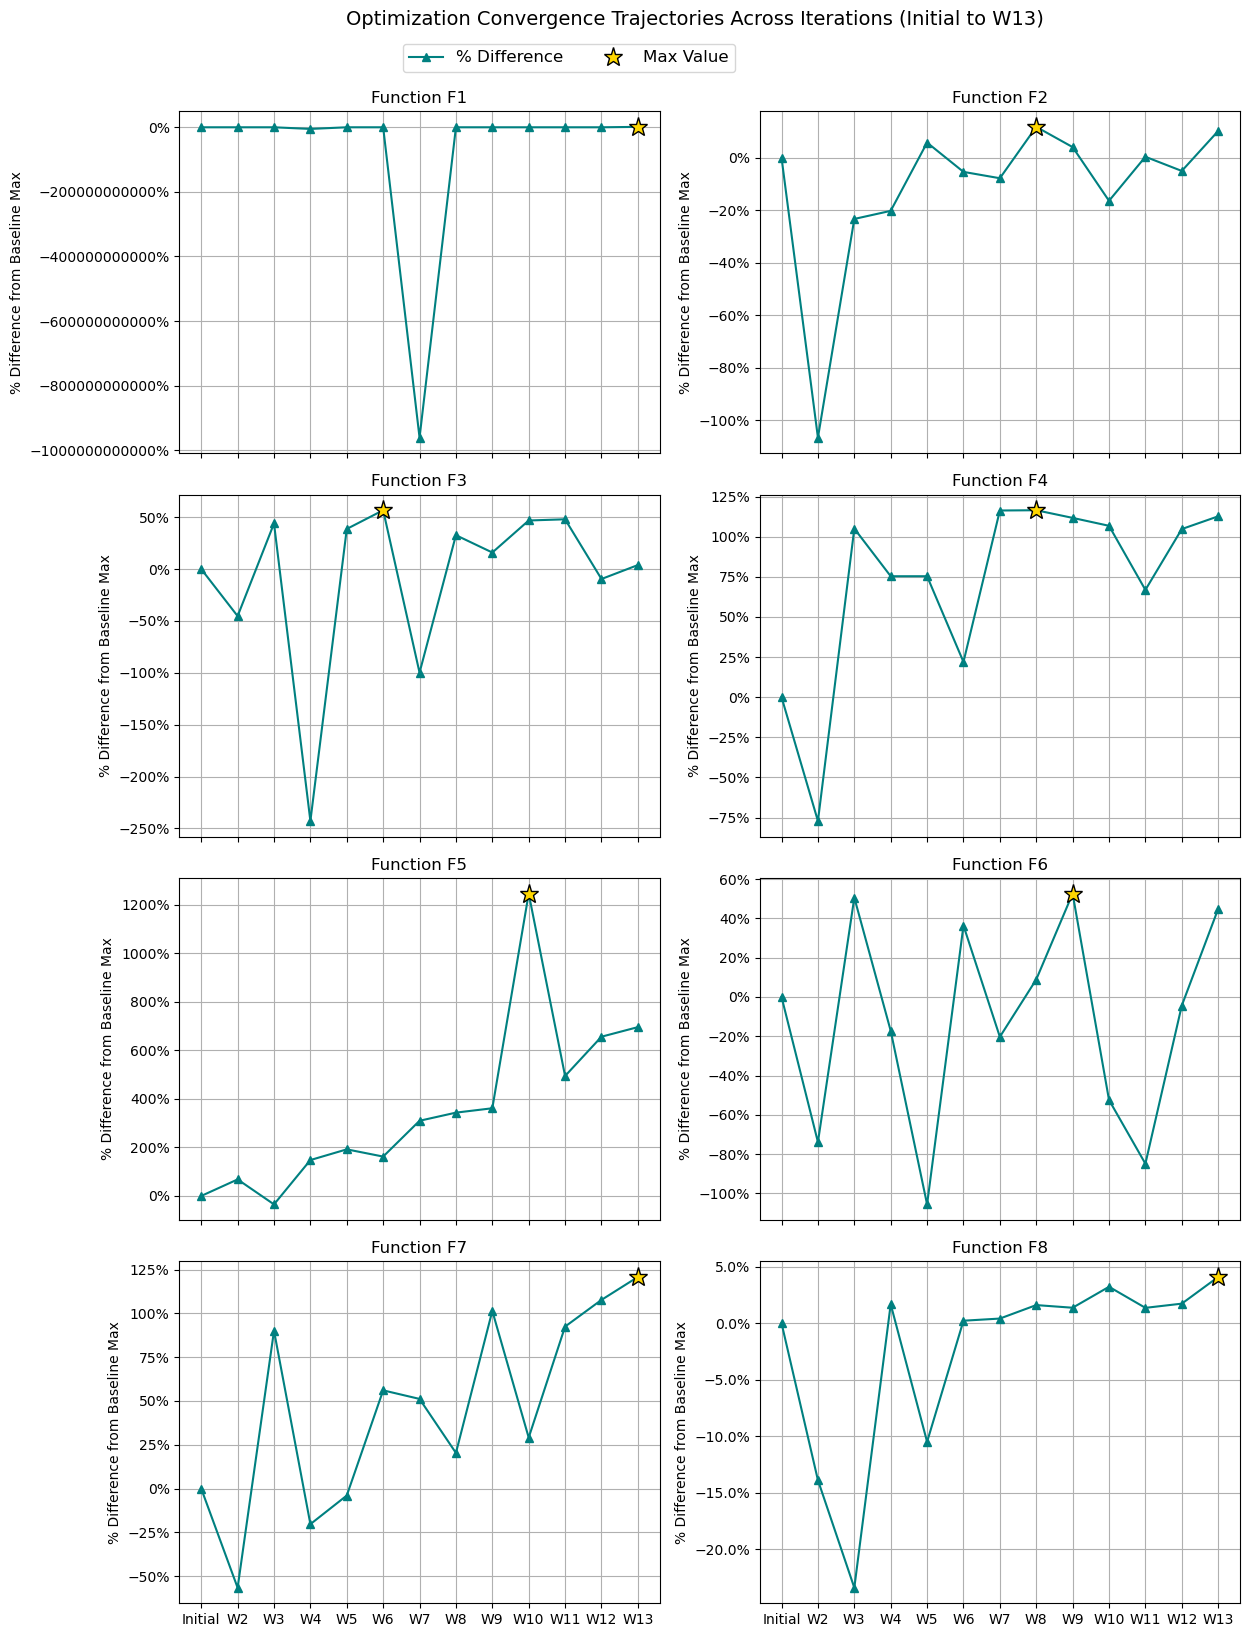

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.ticker as mtick
import numpy as np

# Load the Excel file and extract the Compare2 sheet
file_path = "extended_data/CapstoneFunction_WeeklyOutputs_Compare.xlsx"
df_compare2 = pd.read_excel(file_path, sheet_name='Compare2')

features = [f'F{i}' for i in range(1, 9)]

# Create figure and subplots with space for the external legend
fig, axes = plt.subplots(4, 2, figsize=(14, 16), sharex=True)
axes = axes.flatten()

handles, labels = None, None

for i, feat in enumerate(features):
    ax = axes[i]
    if feat in df_compare2.columns:
        # Convert ratio to percentage
        vals = df_compare2[feat] * 100
        x = df_compare2['Review']
        
        # Plot standard line and markers for % Difference
        line, = ax.plot(x, vals, marker='^', label='% Difference', linestyle='-', color='teal', linewidth=1.5)
        
        # Identify and highlight the maximum value
        valid_vals = vals.dropna()
        if not valid_vals.empty:
            max_idx = valid_vals.idxmax()
            max_x = x.loc[max_idx]
            max_y = valid_vals.loc[max_idx]
            
            # Plot yellow star at the max point
            star = ax.plot(max_x, max_y, marker='*', markersize=14, markerfacecolor='gold', markeredgecolor='black', linestyle='None', label='Max Value')[0]

    ax.set_title(f'Function {feat}')
    ax.set_ylabel('% Difference from Baseline Max')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
    ax.grid(True)
    
    # Capture handles and labels from the first subplot for the shared legend
    if handles is None:
        handles, labels = ax.get_legend_handles_labels()

# Add a shared legend outside the plotting area
fig.legend(handles, labels, loc='center', bbox_to_anchor=(0.41, 0.99), fontsize='large', ncol=2, frameon=True)

fig.suptitle('Optimization Convergence Trajectories Across Iterations (Initial to W13)', fontsize=14, y=1.02)

plt.tight_layout(rect=[0, 0, 0.90, 1])
#plt.savefig('final-bbo-result-plot.png', bbox_inches='tight', dpi=1200)
plt.show()